In [88]:
import numpy as np
import matplotlib.pyplot as plt

def plot_quiver(A, title, color = 'teal'):
    """
    args: 1. the matrix A for the linear system dx/dt = Ax
        2. title for the plot

    Plots the vector field for the linear system defined by matrix A.
    """
    x1 = np.linspace(-2, 2, 20)
    x2 = np.linspace(-2, 2, 20)
    # x1 is repeated along the rows
    # x2 is repeated along the columns
    X1, X2 = np.meshgrid(x1, x2)
    # ravel is the same as flatten but returns a view if possible
    X = np.vstack([X1.ravel(), X2.ravel()]) # each column is a point in the phase plane [x1, x2].T
    # print(X.shape)
    # print(X)
    X_dot = A @ X # multiplying each column, i.e. point by A to get the velocity vector at that point
    U = X_dot[0].reshape(X1.shape) # componetns of the velocity vector at each point at grid shape
    V = X_dot[1].reshape(X2.shape)
    plt.figure(figsize=(5,5))
    plt.quiver(X1, X2, U, V, color= color)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.title(title)
    plt.grid(True)
    plt.show()


### verifing the function 

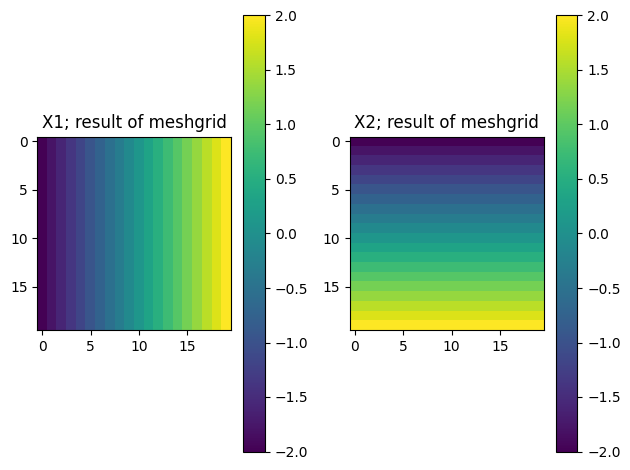

In [89]:
## verify if the function meshgrid and vstack are working as expected

x1 = np.linspace(-2, 2, 20)
x2 = np.linspace(-2, 2, 20)
# x1 is repeated along the rows
# x2 is repeated along the columns
X1, X2 = np.meshgrid(x1, x2)
# ravel is the same as flatten but returns a view if possible
X = np.vstack([X1.ravel(), X2.ravel()])

# plt.figsize((10,5))
plt.subplot(1,2,1)
plt.imshow(X1)
plt.colorbar()
plt.title('X1; result of meshgrid')
plt.subplot(1,2 , 2)
plt.imshow(X2)
plt.title('X2; result of meshgrid')
plt.colorbar()
plt.tight_layout()

(400,)

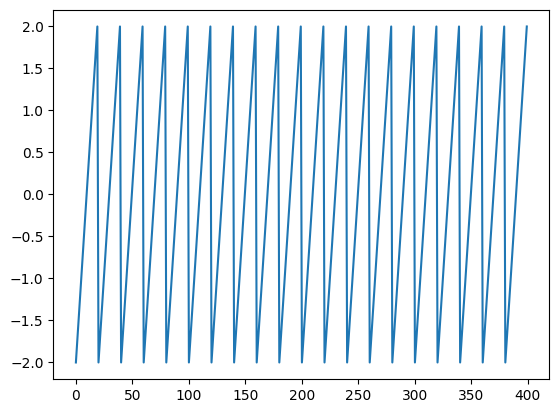

In [90]:
plt.plot(X1.flatten())
X1.flatten().shape

## See resutls

In [124]:
# General check on evals, and evecs using np.linalg.eig

A = np.array([[2, -4], [-1, -1]])
evals, evecs = np.linalg.eig(A)
# evals is [3, -2]
# evecs: [[ 0.9701425   0.70710678] [-0.24253563  0.70710678]]
# the columns are evectors i.e. evecs[:, 0] = [0.9701425, -0.24253563] and evecs[:, 1] = [0.70710678, 0.70710678]

v = [-4, 1]


print('e_vals are\n', evals, '\ne_vecs are\n', evecs)
print("Matrix product: \n", A@evecs[:, 0] )
print("eigenvalue * eigenvector: \n", evals[0]*evecs[:, 0])

e_vals are
 [ 3. -2.] 
e_vecs are
 [[ 0.9701425   0.70710678]
 [-0.24253563  0.70710678]]
Matrix product: 
 [ 2.9104275  -0.72760688]
eigenvalue * eigenvector: 
 [ 2.9104275  -0.72760688]


Eigenvalues:
 [-1. -2.] 
Eigenvectors:
 [[1. 0.]
 [0. 1.]]


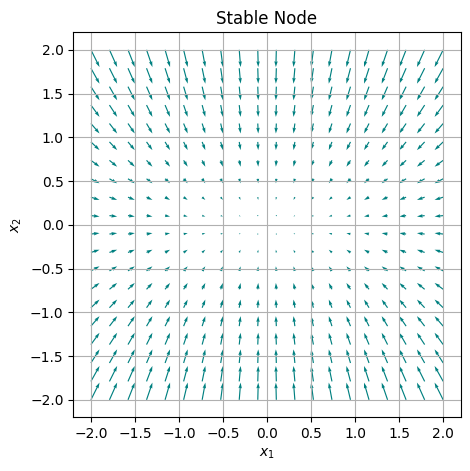

In [91]:
# Stable node: eigenvalues real, negative
A_stable_node = np.array([[-1, 0], [0, -2]])
evals, evecs = np.linalg.eig(A_stable_node)
print("Eigenvalues:\n", evals, "\nEigenvectors:\n", evecs)
plot_quiver(A_stable_node, "Stable Node")


Eigenvalues:
 [1. 2.] 
Eigenvectors:
 [[1. 0.]
 [0. 1.]]


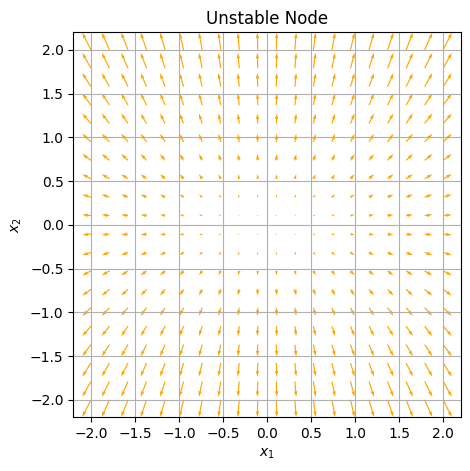

In [ ]:
# Unstable node: eigenvalues real, positive
A_unstable_node = np.array([[1, 0], [0, 2]])
evals, evecs = np.linalg.eig(A_unstable_node)
print("Eigenvalues:\n", evals, "\nEigenvectors:\n", evecs)
plot_quiver(A_unstable_node, "Unstable Node", color  = 'orange')

Eigenvalues:
 [ 1. -1.] 
Eigenvectors:
 [[1. 0.]
 [0. 1.]]


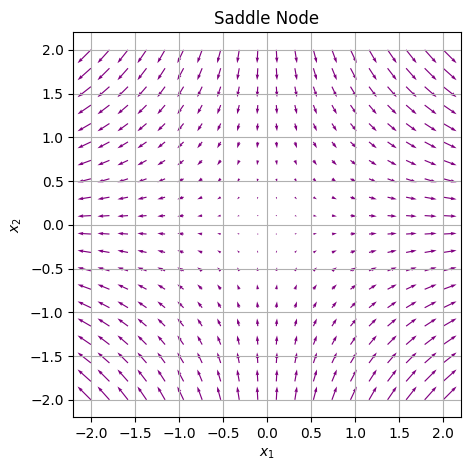

In [97]:
# Saddle node: eigenvalues real, opposite sign
A_saddle_node = np.array([[1, 0], [0, -1]])
evals, evecs = np.linalg.eig(A_saddle_node)
print("Eigenvalues:\n", evals, "\nEigenvectors:\n", evecs)
plot_quiver(A_saddle_node, "Saddle Node", color = 'purple')

Eigenvalues:
 [-0.5+1.j -0.5-1.j] 
Eigenvectors:
 [[0.70710678+0.j         0.70710678-0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j]]


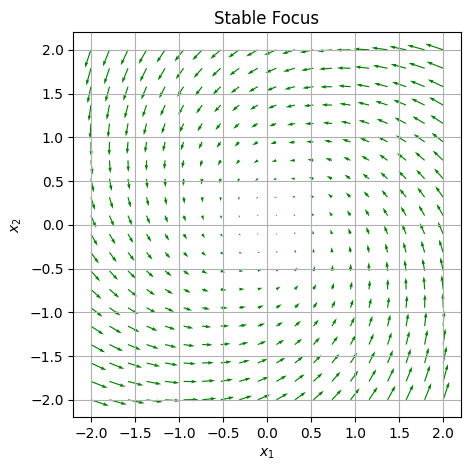

In [ ]:
# Stable focus: eigenvalues complex, negative real part
A_stable_focus = np.array([[-0.5, -1], [1, -0.5]])
evals, evecs = np.linalg.eig(A_stable_focus)
print("Eigenvalues:\n", evals, "\nEigenvectors:\n", evecs)
plot_quiver(A_stable_focus, "Stable Focus", color= 'green')

In [105]:
A_vec1 = A_stable_focus 
E1 = np.array([0.70710678+0.j, 0.70710678-0.j])
E1.shape
A_vec1 @ E1.T

array([-1.06066017+0.j,  0.35355339+0.j])

Eigenvalues:
 [0.5+1.j 0.5-1.j] 
Eigenvectors:
 [[0.70710678+0.j         0.70710678-0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j]]


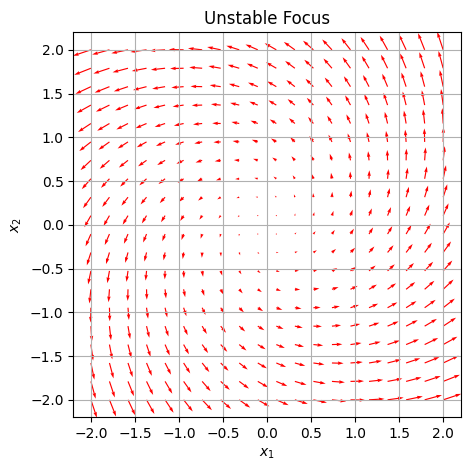

In [ ]:
# Unstable focus: eigenvalues complex, positive real part
A_unstable_focus = np.array([[0.5, -1], [1, 0.5]])
evals, evecs = np.linalg.eig(A_unstable_focus)
print("Eigenvalues:\n", evals, "\nEigenvectors:\n", evecs)

plot_quiver(A_unstable_focus, "Unstable Focus", color = 'red')

Eigenvalues:
 [0.+1.j 0.-1.j] 
Eigenvectors:
 [[0.70710678+0.j         0.70710678-0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j]]


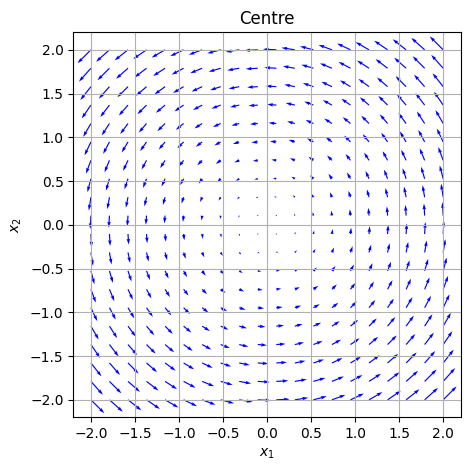

In [96]:
# Centre: eigenvalues purely imaginary
A_centre = np.array([[0, -1], [1, 0]])
evals, evecs = np.linalg.eig(A_centre)
print("Eigenvalues:\n", evals, "\nEigenvectors:\n", evecs)
plot_quiver(A_centre, "Centre", color = 'blue')